<a href="https://colab.research.google.com/github/RanyaSalem/Prediction-of-Product-Sales/blob/main/sales_predictions_visualization_Part_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sales_predictions_2023 (1).csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Data Cleaning


** 1) How many rows and columns?

In [ ]:
rows, cols = df.shape
rows,cols


(8523, 12)

** 2) What are the datatypes of each variable?

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


** 3)Are there duplicates? If so, drop any duplicates.

In [ ]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

4) Identify missing values.

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


5) Address the missing values by using a placeholder value.:


In [ ]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('Missing')
df['Item_Weight'] = df['Item_Weight'].fillna(0)
df['Outlet_Size'].value_counts()


,count
Outlet_Size,
Medium,2793
Missing,2410
Small,2388
High,932


In [ ]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
0.000,1463
12.150,86
17.600,82
13.650,77
11.800,76
...,...
5.210,2
9.420,1
7.685,1


6) Confirm that there are no missing values after addressing them.


In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


7) Find and fix any inconsistent categories of data.

In [ ]:
df['Item_Fat_Content'].value_counts()
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


8) For any numerical columns, obtain the summary statistics.

In [ ]:
statistics = df.describe().loc[['min', 'max', 'mean']]
display(statistics)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,0.00000,0.000000,31.290000,1985.000000,33.290000
max,21.35000,0.328391,266.888400,2009.000000,13086.964800
mean,10.65059,0.066132,140.992782,1997.831867,2181.288914


### Import the libraries for Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Histograms

##### To view the distributions of numerical features in your datase

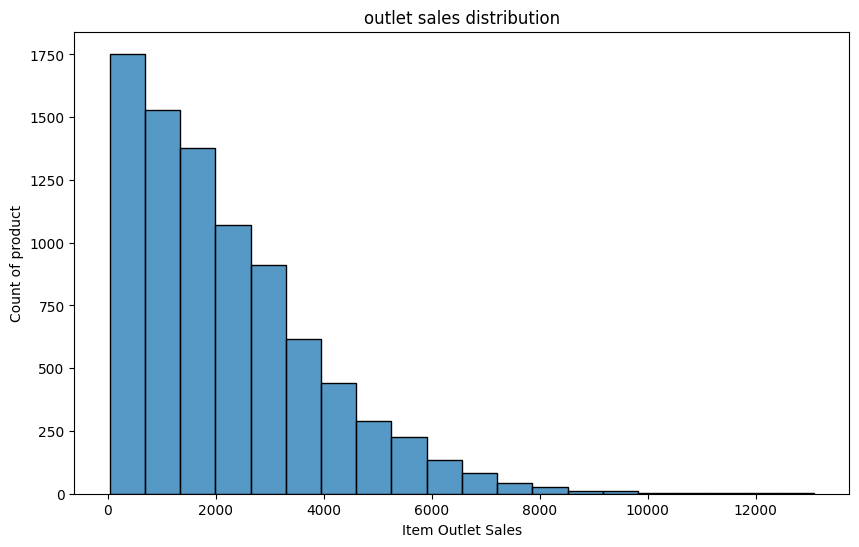

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Item_Outlet_Sales', bins=20)
plt.title('outlet sales distribution')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Count of product')
plt.show()

### Boxplots

 #### To view statistical summaries of numerical features in your dataset.

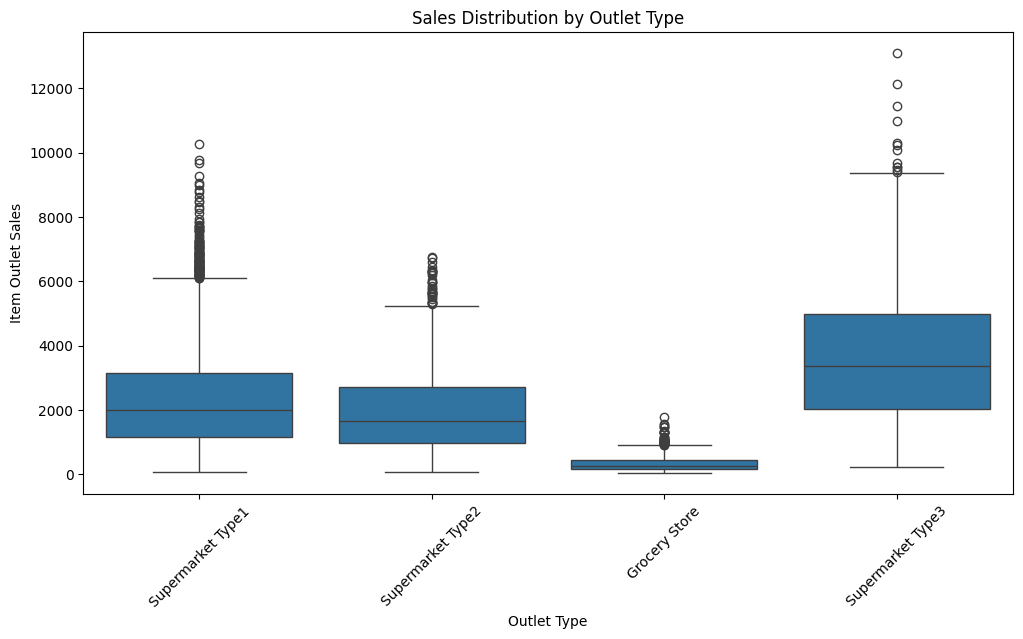

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.title('Sales Distribution by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Item Outlet Sales')
plt.show()

### Countplots
##### to view the frequency of each class of categorial features in your dataset.


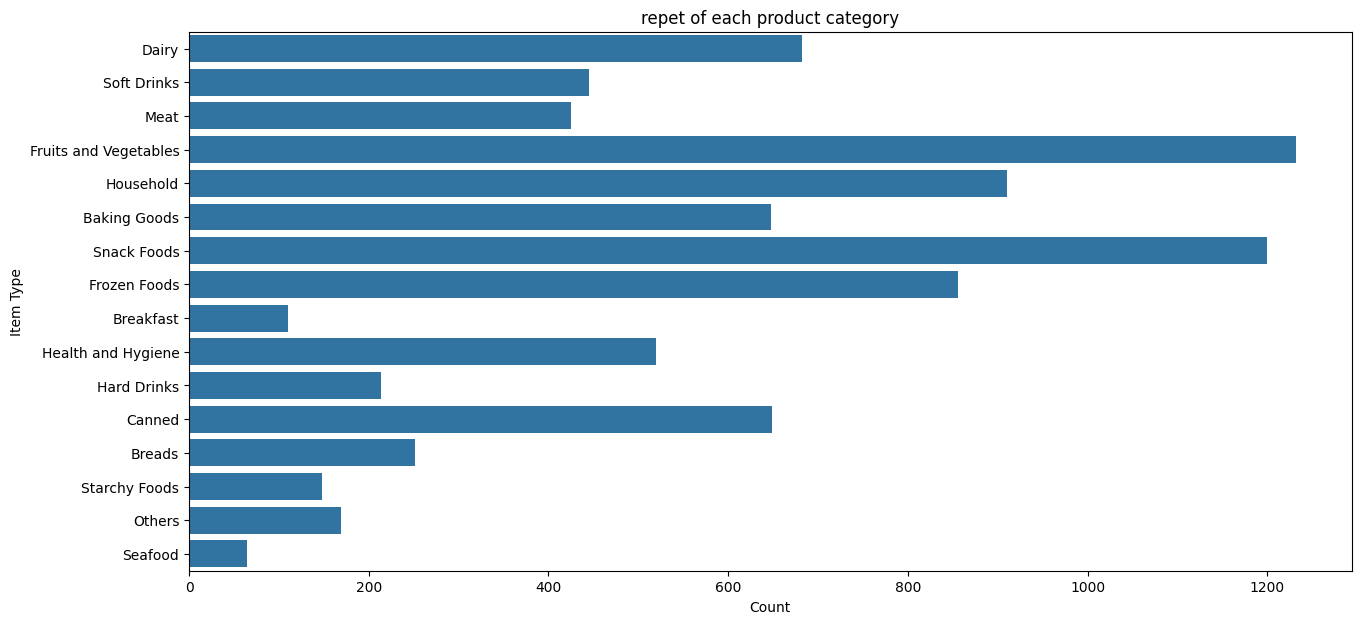

In [ ]:
plt.figure(figsize=(15, 7))
order = df['Item_Type'].value_counts()
sns.countplot(data=df, y='Item_Type')
plt.title('repet of each product category')
plt.xlabel('Count')
plt.ylabel('Item Type')
plt.show()

### Heatmap
#### To view the correlation between features.

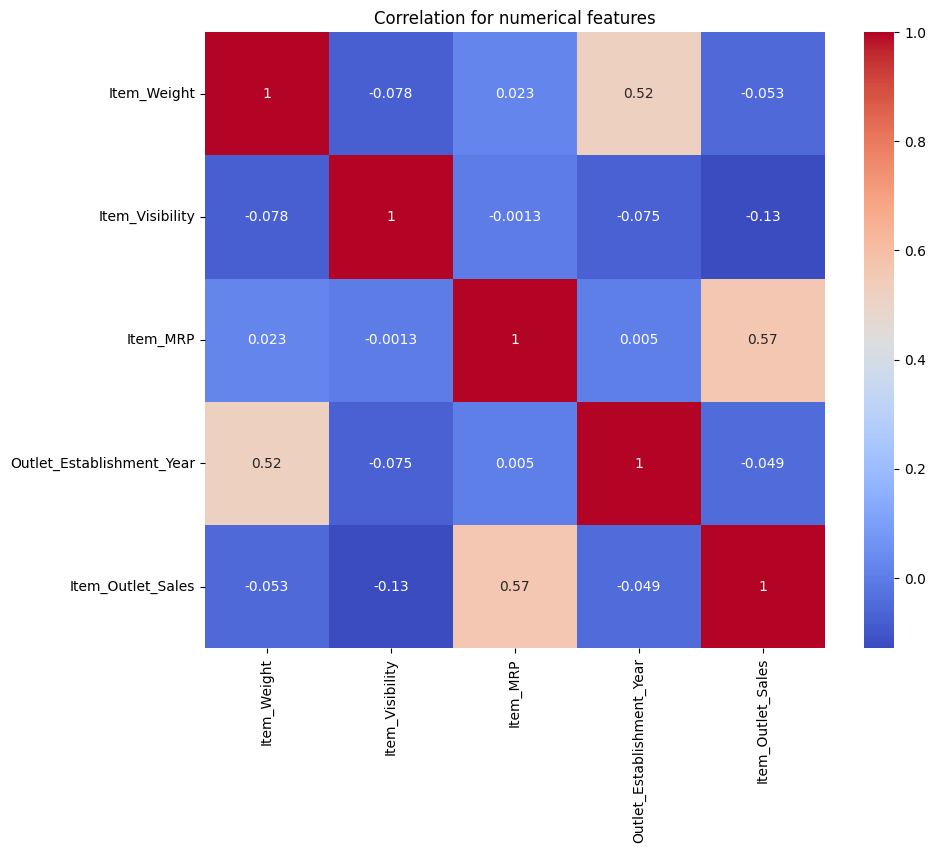

In [ ]:
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation for numerical features')
plt.show()

#### Reverting Week 2 Placeholders to True Null Values

In [ ]:
#df['Outlet_Size'] = df['Outlet_Size'].fillna('Missing')
#df['Item_Weight'] = df['Item_Weight'].fillna(0)

df['Outlet_Size'] = df['Outlet_Size'].replace('Unknown', np.nan)
df['Item_Weight'] = df['Item_Weight'].replace(0, np.nan)
print(df.isna().sum())

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


### Phase 2: Feature Inspection

In [ ]:
null_counts = df.isnull().sum()
null_counts

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


#### 1. Item_MRP: Maximum Retail Price (list price) of the product.



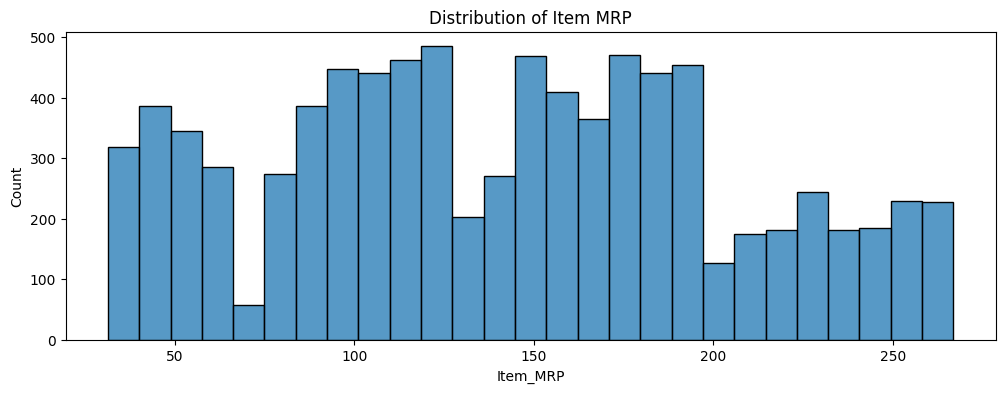

In [ ]:
plt.figure(figsize=(12,4))
sns.histplot(data=df, x='Item_MRP')
plt.title('Distribution of Item MRP')
plt.show()

#### Feature Inspection

What type of feature is it?

  >**Numeric (Continuous).**

How many null values? What percentage? What would you do?

 >**0 null values.**

Is the feature constant or quasi-constant?

 >**No.**

What is the cardinality? Is it high (>10)?

 >**High, Continuous values have high unique counts.**

Would we know this feature before the target is determined?

>**Yes, the list price is set before the sale occurs.**

Is there a business case reason to exclude it?

>**No, keep it.**

Based on business understanding, would you expect it to be a predictor?

>**Yes, a higher-priced item inherently generates more sales revenue.**

Does this feature appear to be a predictor of the target?

>**Highly, maximum sales scale directly upward as MRP increases.**

2. Item_Visibility: The percentage of total display area of all products in a store allocated to the particular product.

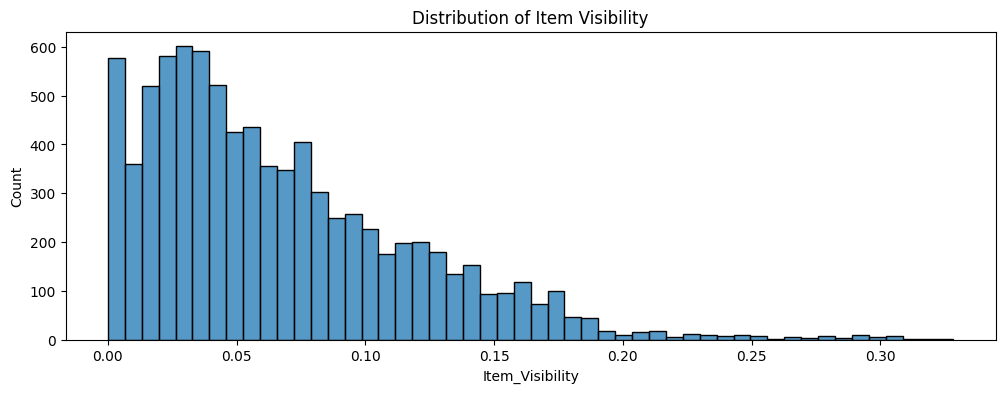

In [ ]:
plt.subplots(figsize=(12, 4))
sns.histplot(data=df, x='Item_Visibility')
plt.title('Distribution of Item Visibility')
plt.show()

What type of feature is it?

 > **Numeric (Continuous).:**

How many null values? What percentage? What would you do?
 >**0 standard nulls**

Is the feature constant or quasi-constant?
 >**No.**

What is the cardinality? Is it high (>10)?
 > **High.**

Would we know this feature before the target is determined?

> **Yes, determined by the store's shelf management placement.**

Is there a business case reason to exclude it?

 > **No, product placement strategies directly impact item discoverability.**

Based on business understanding, would you expect it to be a predictor?

 > **Yes, items placed prominently at eye level or end-caps usually attract more impulse buys.**

Does this feature appear to be a predictor of the target?

 > **Yes, but non-linearly. Items with moderate visibility sell well, but once visibility exceeds a certain high threshold, sales drop off, likely indicating clearance items or overstocked slower-moving products.**

3. Outlet_Size: The size of the store in terms of ground area covered.

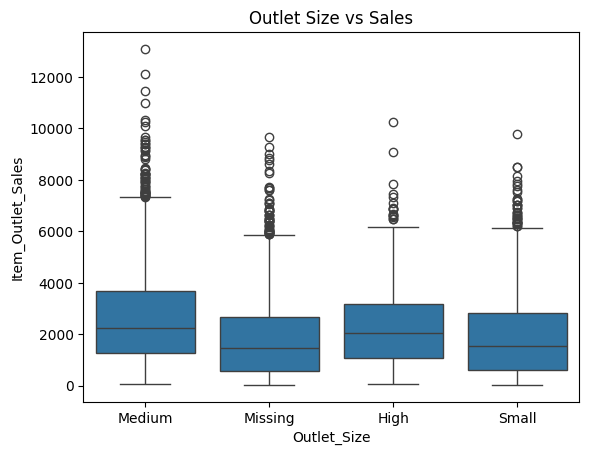

In [ ]:
plt.subplotsfigsize=(12, 4)
sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales')
plt.title('Outlet Size vs Sales')
plt.show()

What type of feature is it?

> **Categorical**

How many null values? What percentage? What would you do?

 > **2,410 values.**


Is the feature constant or quasi-constant?  
> **No.**

What is the cardinality? Is it high (>10)?
 > **Low**

Would we know this feature before the target is determined?

 > **Yes.**

Is there a business case reason to exclude it?

 > **No, square footage influences
 product variety and capacity.**

Based on business understanding, would you expect it to be a predictor?
> **Yes, larger floor spaces can comfortably handle more foot traffic and variety, driving up volume.**

Does this feature appear to be a predictor of the target?

> **Medium and High size outlets display higher overall distribution caps and slightly higher medians compared to Small locations.**